# Imbalanced Text Classification - Disaster Tweets

**Course:** CS3012E Artificial Intelligence  
**Team Members:** Gowri Sankar P, 
                 Neeraj S,
                 Pankaj Kumar R, 
                 Nithin R, 
                 Naveena Mariya Johnson

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("dataset.csv") 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11370 entries, 0 to 11369
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        11370 non-null  int64 
 1   keyword   11370 non-null  object
 2   location  7952 non-null   object
 3   text      11370 non-null  object
 4   target    11370 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 444.3+ KB


In [3]:
df['target'].value_counts()

target
0    9256
1    2114
Name: count, dtype: int64

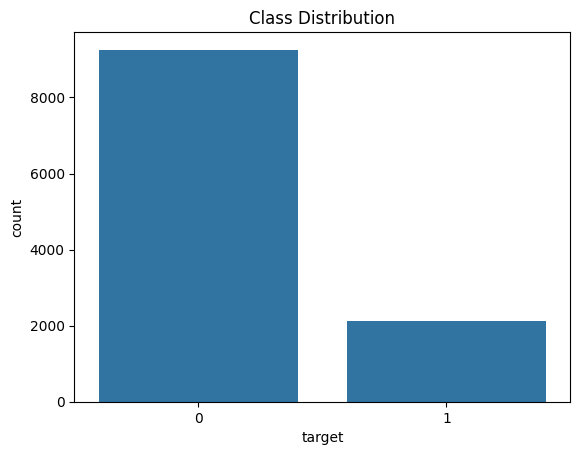

In [4]:
sns.countplot(x='target', data=df)
plt.title("Class Distribution")
plt.show()

In [5]:
#cleaning

import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
import emoji
import urllib.parse
import re # Regular expressions
import unicodedata

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4') # Open Multilingual Wordnet (for lemmatization)

def clean_text(text):
    text = urllib.parse.unquote(text) # Fix encoding issues
    text = text.lower() 
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'<.*?>', '', text) # Remove HTML tags
    text = emoji.demojize(text) # Convert emojis to text
    text = re.sub('\W+',' ',text) # Remove all non-word characters
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore') # Normalize unicode to ascii
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove punctuation and numbers

    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    cleaned_text = ' '.join(cleaned_words)

    return cleaned_text
    

df['clean_text'] = (
    df['text']
    # .fillna('') 
    .astype(str)
    # .agg(' '.join, axis=1) 
    .str.replace(r'\s+', ' ', regex=True) # Replace multiple spaces with a single space
    .str.strip() # Remove leading and trailing whitespace
    .apply(clean_text)
)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\panka\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\panka\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\panka\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [6]:
#TF-IDF
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text']).toarray()
y = df['target']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42 # 70-30 split
)

### Part A: witout imbalance handling

#### Logistical Regression

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score

param_grid = {
    'penalty': ['l1', 'l2'],                  # Regularization types 
    'C': [0.001, 0.01, 0.1, 1, 10],           # Regularization strengths 
    'solver': ['liblinear'],                  # 'liblinear' supports both l1 and l2
}

lr = LogisticRegression()
grid_search = GridSearchCV(lr, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# See the best parameters
print("Best Parameters:", grid_search.best_params_)

# Use the best model found
best_lr = grid_search.best_estimator_

y_probs = best_lr.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_test, (y_probs >= t).astype(int)) for t in thresholds]

# Identify the threshold with the maximum F1-score
ix = np.argmax(f1_scores)
best_threshold = thresholds[ix]
print(f'Best Threshold={best_threshold:.2f}, F1-Score={f1_scores[ix]:.3f}')

y_pred = (y_probs >= best_threshold).astype(int)


Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best Threshold=0.36, F1-Score=0.663


In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.93      0.93      2777
           1       0.69      0.64      0.66       634

    accuracy                           0.88      3411
   macro avg       0.80      0.79      0.79      3411
weighted avg       0.88      0.88      0.88      3411



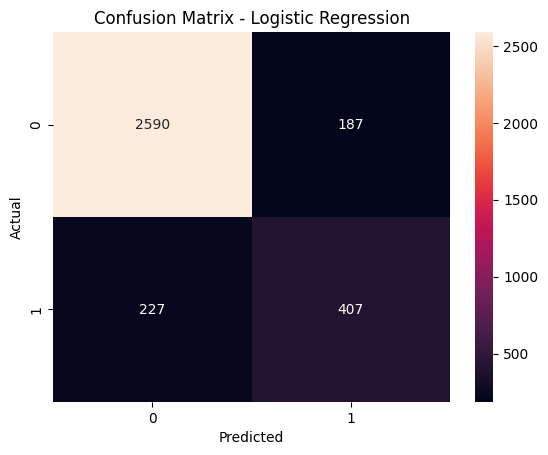

In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [11]:
from sklearn.metrics import roc_auc_score

print("ROC-AUC:", roc_auc_score(y_test, y_probs))

ROC-AUC: 0.8958547510022049


#### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    'n_estimators': [100, 200],          # Number of trees 
    'max_depth': [10, 20, None],         # Maximum depth 
    'min_samples_split': [2, 5],         # Min samples split 
    'min_samples_leaf': [1, 2],          # Min samples leaf 
}

rf_grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42), 
    rf_param_grid, 
    cv=3, 
    scoring='f1_macro', 
    n_jobs=-1
)

rf_grid_search.fit(X_train, y_train)
print("Best RF Params:", rf_grid_search.best_params_)

rf_best_estimator = rf_grid_search.best_estimator_
rf_y_probs = rf_best_estimator.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_test, (rf_y_probs >= t).astype(int)) for t in thresholds]

ix = np.argmax(f1_scores)
rf_best_threshold = thresholds[ix]
print(f'Best Threshold={rf_best_threshold:.2f}, F1-Score={f1_scores[ix]:.3f}')

y_pred_rf = (rf_y_probs >= rf_best_threshold).astype(int)

print(classification_report(y_test, y_pred_rf))

Best RF Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best Threshold=0.37, F1-Score=0.647
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      2777
           1       0.66      0.64      0.65       634

    accuracy                           0.87      3411
   macro avg       0.79      0.78      0.78      3411
weighted avg       0.87      0.87      0.87      3411



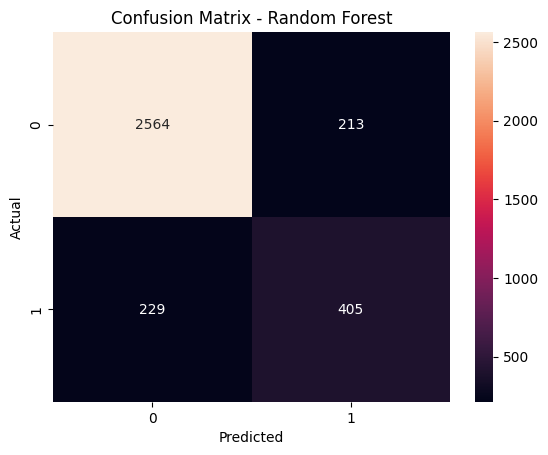

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [16]:
from sklearn.metrics import roc_curve, roc_auc_score

print("ROC-AUC:", roc_auc_score(y_test, rf_y_probs))

ROC-AUC: 0.8935248872838969


In [12]:
#NN Input → 64 → 32 → 16 → Output (sigmoid)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [17]:
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.regularizers import l2

def create_model(activation='relu', optimizer='adam', dropout_rate=0.2, l2_reg=0.01, init='glorot_uniform'):
    model = Sequential([
        Dense(64, activation=activation, kernel_initializer=init, 
              kernel_regularizer=l2(l2_reg), input_shape=(X_train.shape[1],)),
        Dropout(dropout_rate),
        Dense(32, activation=activation, kernel_initializer=init, 
              kernel_regularizer=l2(l2_reg)),
        Dropout(dropout_rate),
        Dense(16, activation=activation, kernel_initializer=init, 
              kernel_regularizer=l2(l2_reg)),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid') # Fixed output layer [cite: 43]
    ])
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# 2. Wrap the model for sklearn
nn_model = KerasClassifier(model=create_model, verbose=0)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__activation': ['relu', 'leaky_relu', 'tanh', 'elu'],
    'model__optimizer': ['adam', 'rmsprop'],
    'model__dropout_rate': [0.2, 0.5],
    'model__l2_reg': [0.001, 0.01],
    'model__init': ['glorot_uniform', 'he_normal'],
    'batch_size': [32, 64],
    'epochs': [20]
}

# 4. Run Grid Search
nn_grid_search = GridSearchCV(estimator=nn_model, param_grid=param_grid, cv=3, scoring='f1_macro', n_jobs=10)
grid_result = nn_grid_search.fit(X_train, y_train)

nn_best_estimator = grid_result.best_estimator_

print(f"Best: {grid_result.best_score_} using {grid_result.best_params_}")

In [16]:
from sklearn.metrics import f1_score # <--- ADD THIS LINE

# Generate probabilities
nn_probs = nn_best_estimator.predict_proba(X_test)[:, 1]

# Test different thresholds
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_test, (nn_probs >= t).astype(int)) for t in thresholds]

# Find the best threshold
ix = np.argmax(f1_scores)
nn_best_threshold = thresholds[ix]
print(f'Best Threshold={nn_best_threshold:.2f}, F1-Score={f1_scores[ix]:.3f}')

# Generate final predictions based on the best threshold
y_pred_nn = (nn_probs >= nn_best_threshold).astype(int)

NameError: name 'nn_best_estimator' is not defined

In [19]:
print(classification_report(y_test, y_pred_nn))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92      2777
           1       0.63      0.64      0.64       634

    accuracy                           0.86      3411
   macro avg       0.78      0.78      0.78      3411
weighted avg       0.86      0.86      0.86      3411



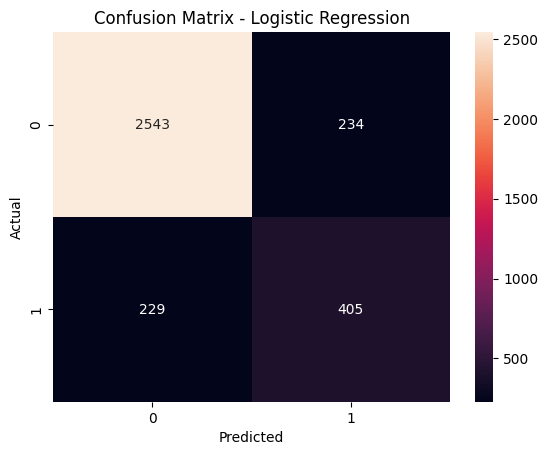

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_nn)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [22]:
print("ROC-AUC:", roc_auc_score(y_test, nn_probs))

ROC-AUC: 0.8663344348404934


In [26]:
# Access the underlying Keras model from the Scikeras wrapper
best_keras_model = nn_best_estimator.model_

# Print the architecture summary
best_keras_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │         320,064 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 645,380 (2.46 MB)

 Trainable params: 322,689 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 322,691 (1.23 MB)

In [25]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

NameError: name 'model' is not defined

In [27]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

NameError: name 'model' is not defined

In [41]:
y_prob_nn = model.predict(X_test)
y_pred_nn = (y_prob_nn > 0.5).astype(int)

NameError: name 'model' is not defined

In [29]:
print(classification_report(y_test, y_pred_nn))
print("ROC-AUC:", roc_auc_score(y_test, nn_probs))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92      2777
           1       0.63      0.64      0.64       634

    accuracy                           0.86      3411
   macro avg       0.78      0.78      0.78      3411
weighted avg       0.86      0.86      0.86      3411

ROC-AUC: 0.8663344348404934


In [69]:
#Part B WITH imbalance handling 

In [30]:
#SMOTE
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

In [31]:
import pandas as pd
print(pd.Series(y_train_sm).value_counts())

target
0    6479
1    6479
Name: count, dtype: int64


In [32]:
# Logistic Regression with SMOTE
lr_sm = LogisticRegression()
lr_sm.fit(X_train_sm, y_train_sm)

y_pred_sm = lr_sm.predict(X_test)

print(classification_report(y_test, y_pred_sm))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_sm))

NameError: name 'LogisticRegression' is not defined

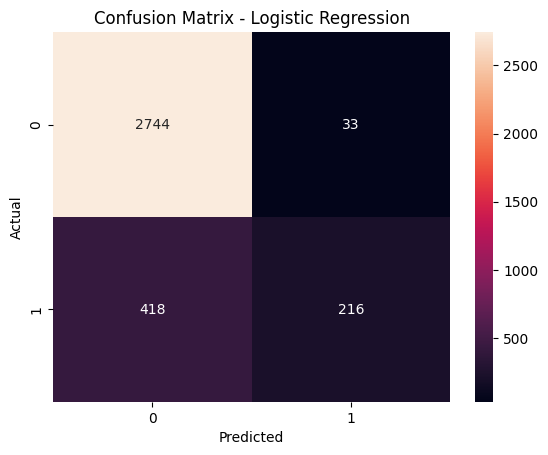

In [57]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [58]:
#random forest with SMOTE
rf_sm = RandomForestClassifier(n_estimators=50, max_depth=10)
rf_sm.fit(X_train_sm, y_train_sm)

y_pred_rf_sm = rf_sm.predict(X_test)
print(classification_report(y_test, y_pred_rf_sm))
y_prob_rf_sm = rf_sm.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_sm))

              precision    recall  f1-score   support

           0       0.88      0.95      0.91      2777
           1       0.65      0.44      0.52       634

    accuracy                           0.85      3411
   macro avg       0.76      0.69      0.72      3411
weighted avg       0.84      0.85      0.84      3411

ROC-AUC: 0.8278377251624146


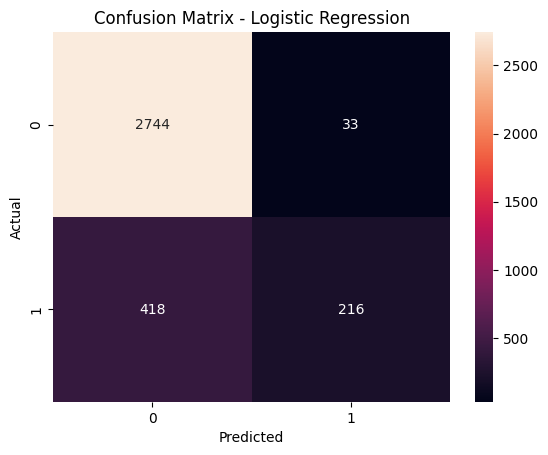

In [59]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from sklearn.metrics import f1_score, classification_report, roc_auc_score
import numpy as np

# 1. Define the model building function for SMOTE data
def create_nn_model_sm(activation='relu', optimizer='adam', learning_rate=0.001, 
                       l2_reg=0.001, dropout_rate=0.2, init_mode='glorot_uniform'):
    
    model = Sequential()
    
    # Input layer & Hidden Layer 1: 64 neurons (Updated for X_train_sm)
    model.add(Dense(64, activation=activation, 
                    kernel_initializer=init_mode,
                    kernel_regularizer=l2(l2_reg),
                    input_shape=(X_train_sm.shape[1],)))
    model.add(Dropout(dropout_rate)) 
    
    # Hidden Layer 2: 32 neurons
    model.add(Dense(32, activation=activation, 
                    kernel_initializer=init_mode,
                    kernel_regularizer=l2(l2_reg)))
    model.add(Dropout(dropout_rate))
    
    # Hidden Layer 3: 16 neurons
    model.add(Dense(16, activation=activation, 
                    kernel_initializer=init_mode,
                    kernel_regularizer=l2(l2_reg)))
    model.add(Dropout(dropout_rate))
    
    # Output Layer (sigmoid activation)
    model.add(Dense(1, activation='sigmoid'))
    
    # Configure Optimizer
    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == 'sgd':
        opt = SGD(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
        
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# 2. Wrap the model for Scikit-Learn compatibility
nn_model_sm = KerasClassifier(
    model=create_nn_model_sm, 
    verbose=0
)

# 3. Define the exact same parameter grid
param_dist = {
    'model__activation': ['relu', 'leaky_relu', 'tanh', 'elu'],
    'model__optimizer': ['adam', 'sgd', 'rmsprop'],
    'model__learning_rate': [0.01, 0.001, 0.0001],
    'model__l2_reg': [1e-4, 1e-3, 1e-2],
    'model__dropout_rate': [0.1, 0.2, 0.3, 0.4],
    'model__init_mode': ['glorot_uniform', 'he_normal'],
    'batch_size': [32, 64, 128],
    'epochs': [10, 20]
}

# 4. Perform RandomizedSearchCV (n_jobs=1 is CRITICAL here)
random_search_sm = RandomizedSearchCV(
    estimator=nn_model_sm, 
    param_distributions=param_dist, 
    n_iter=10,  
    cv=3, 
    scoring='f1_macro', 
    n_jobs=1,
    random_state=42
)

# Fit using the SMOTE-balanced training data!
random_search_sm.fit(X_train_sm, y_train_sm)

print("Best Parameters (SMOTE):", random_search_sm.best_params_)

# 5. Tune Decision Threshold and Evaluate
best_nn_sm = random_search_sm.best_estimator_
nn_probs_sm = best_nn_sm.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores_sm = [f1_score(y_test, (nn_probs_sm >= t).astype(int)) for t in thresholds]

ix = np.argmax(f1_scores_sm)
nn_best_threshold_sm = thresholds[ix]
print(f'Best Threshold (SMOTE)={nn_best_threshold_sm:.2f}, F1-Score={f1_scores_sm[ix]:.3f}')

# Generate final predictions
y_pred_nn_sm = (nn_probs_sm >= nn_best_threshold_sm).astype(int)

# 6. Final Evaluation Metrics for Part B
print("\n--- SMOTE Neural Network Results ---")
print(classification_report(y_test, y_pred_nn_sm))
print("ROC-AUC (SMOTE):", roc_auc_score(y_test, nn_probs_sm))

Best Parameters (SMOTE): {'model__optimizer': 'adam', 'model__learning_rate': 0.001, 'model__l2_reg': 0.0001, 'model__init_mode': 'glorot_uniform', 'model__dropout_rate': 0.3, 'model__activation': 'leaky_relu', 'epochs': 20, 'batch_size': 64}
Best Threshold (SMOTE)=0.86, F1-Score=0.636

--- SMOTE Neural Network Results ---
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      2777
           1       0.66      0.61      0.64       634

    accuracy                           0.87      3411
   macro avg       0.79      0.77      0.78      3411
weighted avg       0.87      0.87      0.87      3411

ROC-AUC (SMOTE): 0.8688068621359091


PR-AUC (SMOTE): 0.6864


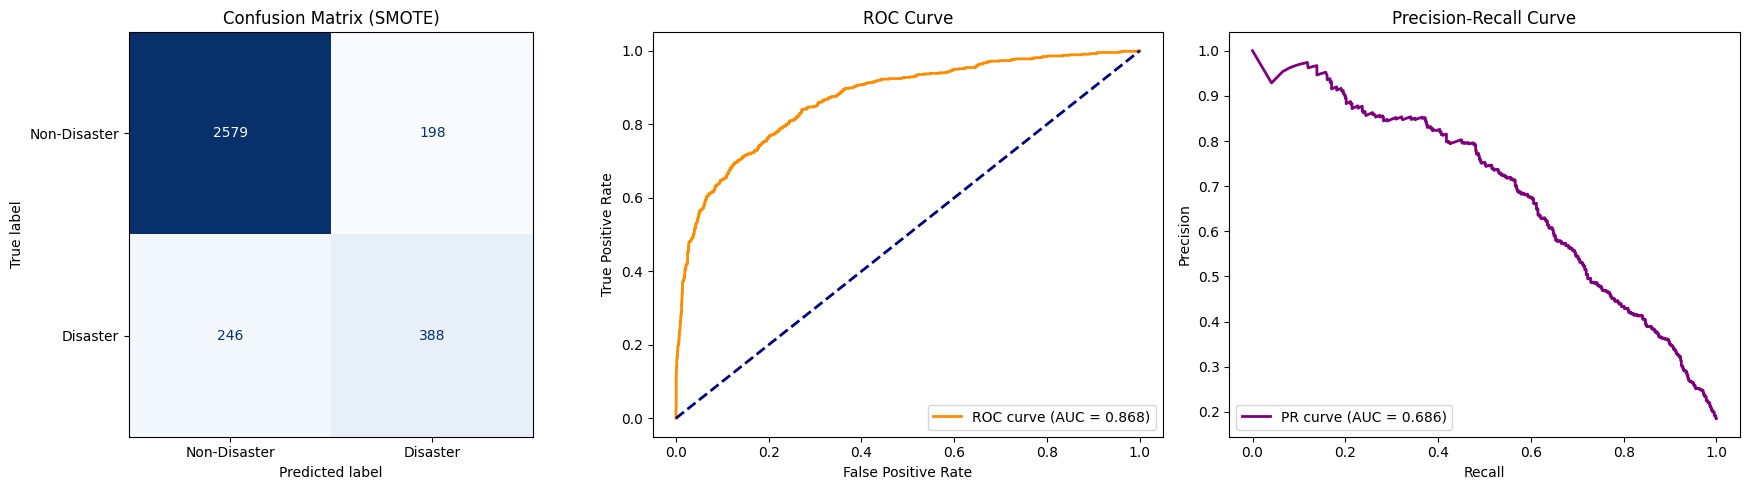

In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve, auc

# 1. Calculate PR-AUC
precision, recall, _ = precision_recall_curve(y_test, nn_probs_sm)
pr_auc_sm = auc(recall, precision)
print(f"PR-AUC (SMOTE): {pr_auc_sm:.4f}")

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_nn_sm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Disaster', 'Disaster'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (SMOTE)')

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, nn_probs_sm)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {0.868:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc="lower right")

# 4. Precision-Recall Curve
axes[2].plot(recall, precision, color='purple', lw=2, label=f'PR curve (AUC = {pr_auc_sm:.3f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend(loc="lower left")

plt.tight_layout()
plt.show()

In [34]:
y_prob_nn_sm = model_sm.predict(X_test)
y_pred_nn_sm = (y_prob_nn_sm > 0.5).astype(int)

print(classification_report(y_test, y_pred_nn_sm))

NameError: name 'model_sm' is not defined

In [78]:
#LOG REG WITH CLASS WEIGHTS
lr_w = LogisticRegression(class_weight='balanced')
lr_w.fit(X_train, y_train)

y_pred_w = lr_w.predict(X_test)

print(classification_report(y_test, y_pred_w))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_w))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91      1851
           1       0.59      0.75      0.66       423

    accuracy                           0.86      2274
   macro avg       0.77      0.82      0.79      2274
weighted avg       0.88      0.86      0.86      2274

ROC-AUC: 0.8176412213447974


In [80]:
rf_w = RandomForestClassifier(n_estimators=50, max_depth=10, class_weight='balanced')
rf_w.fit(X_train, y_train)

y_pred_rf_w = rf_w.predict(X_test)

print(classification_report(y_test, y_pred_rf_w))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf_w))

              precision    recall  f1-score   support

           0       0.89      0.92      0.90      1851
           1       0.58      0.49      0.53       423

    accuracy                           0.84      2274
   macro avg       0.73      0.70      0.72      2274
weighted avg       0.83      0.84      0.83      2274

ROC-AUC: 0.7032503036503175


In [82]:
#NN with class weights
class_weights = {0: 1, 1: 4}  # because imbalance ~4:1


In [37]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from sklearn.metrics import f1_score, classification_report, roc_auc_score
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# 1. Calculate the weights automatically to balance the classes
weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# 2. Convert the array into a dictionary format that Keras requires
class_weights = dict(enumerate(weights_array))
print("Applying Class Weights:", class_weights)

# 3. Now run the fit method!
random_search_w.fit(X_train, y_train, class_weight=class_weights)

print("Best Parameters (Class Weights):", random_search_w.best_params_)

# 5. Tune Decision Threshold
best_nn_w = random_search_w.best_estimator_
nn_probs_w = best_nn_w.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores_w = [f1_score(y_test, (nn_probs_w >= t).astype(int)) for t in thresholds]

ix = np.argmax(f1_scores_w)
nn_best_threshold_w = thresholds[ix]
print(f'Best Threshold (Class Weights)={nn_best_threshold_w:.2f}, F1-Score={f1_scores_w[ix]:.3f}')

# Generate final predictions
y_pred_nn_w = (nn_probs_w >= nn_best_threshold_w).astype(int)

# 6. Final Evaluation Metrics
print("\n--- Class Weighted Neural Network Results ---")
print(classification_report(y_test, y_pred_nn_w))
print("ROC-AUC (Class Weights):", roc_auc_score(y_test, nn_probs_w))

Applying Class Weights: {0: np.float64(0.6142151566599784), 1: np.float64(2.6888513513513512)}
Best Parameters (Class Weights): {'model__optimizer': 'adam', 'model__learning_rate': 0.0001, 'model__l2_reg': 0.001, 'model__init_mode': 'he_normal', 'model__dropout_rate': 0.4, 'model__activation': 'elu', 'epochs': 20, 'batch_size': 64}
Best Threshold (Class Weights)=0.77, F1-Score=0.651

--- Class Weighted Neural Network Results ---
              precision    recall  f1-score   support

           0       0.91      0.94      0.93      2777
           1       0.70      0.61      0.65       634

    accuracy                           0.88      3411
   macro avg       0.81      0.77      0.79      3411
weighted avg       0.87      0.88      0.88      3411

ROC-AUC (Class Weights): 0.8851278357940224


In [40]:
# Predict using your dynamically tuned threshold instead of 0.5
y_pred_nn_w = (y_prob_nn_w >= nn_best_threshold_w).astype(int)

# Print the final metrics for the report
print(f"\n--- Class Weighted Neural Network Results (Threshold: {nn_best_threshold_w:.2f}) ---")
print(classification_report(y_test, y_pred_nn_w))
print("ROC-AUC (Class Weights):", roc_auc_score(y_test, y_prob_nn_w))


--- Class Weighted Neural Network Results (Threshold: 0.77) ---
              precision    recall  f1-score   support

           0       0.91      0.94      0.93      2777
           1       0.70      0.61      0.65       634

    accuracy                           0.88      3411
   macro avg       0.81      0.77      0.79      3411
weighted avg       0.87      0.88      0.88      3411

ROC-AUC (Class Weights): 0.8851278357940224
